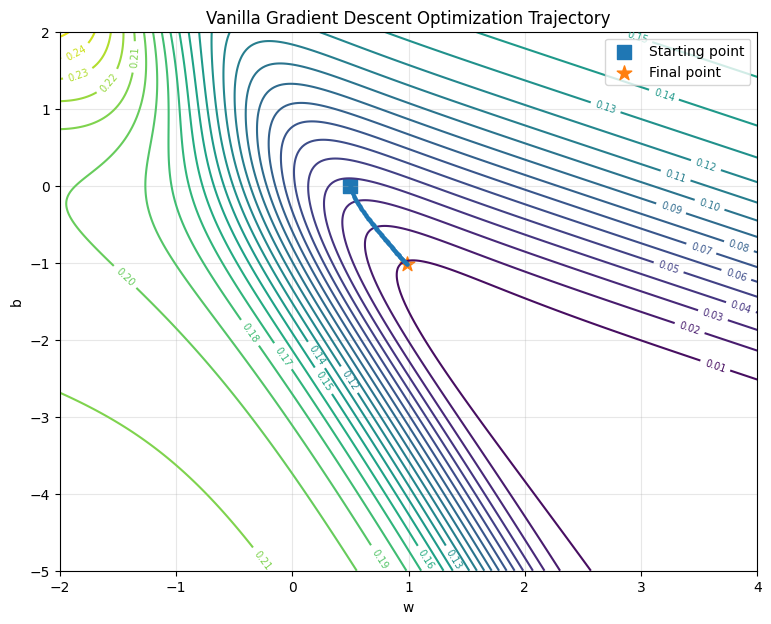

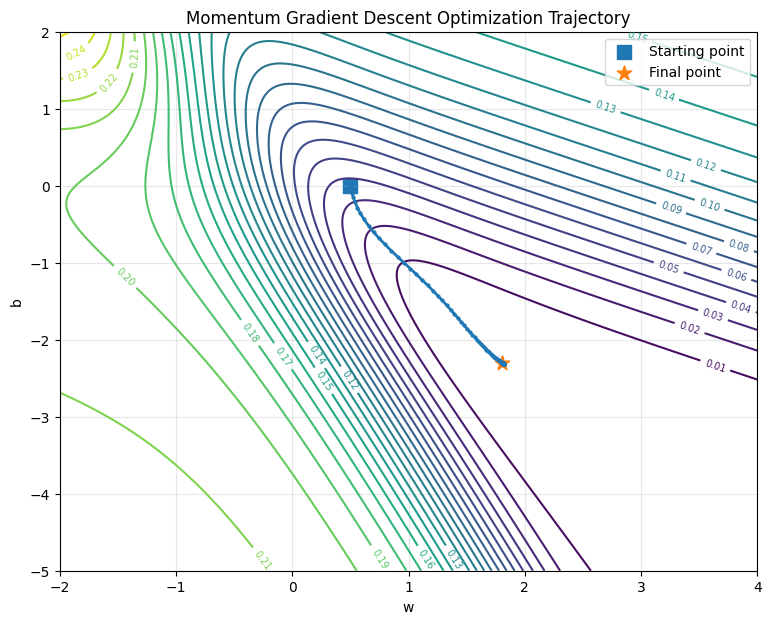

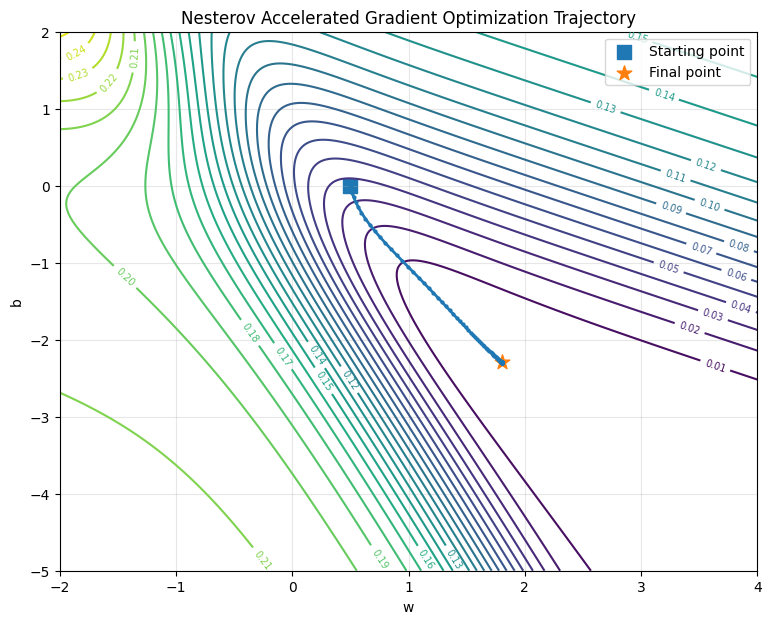

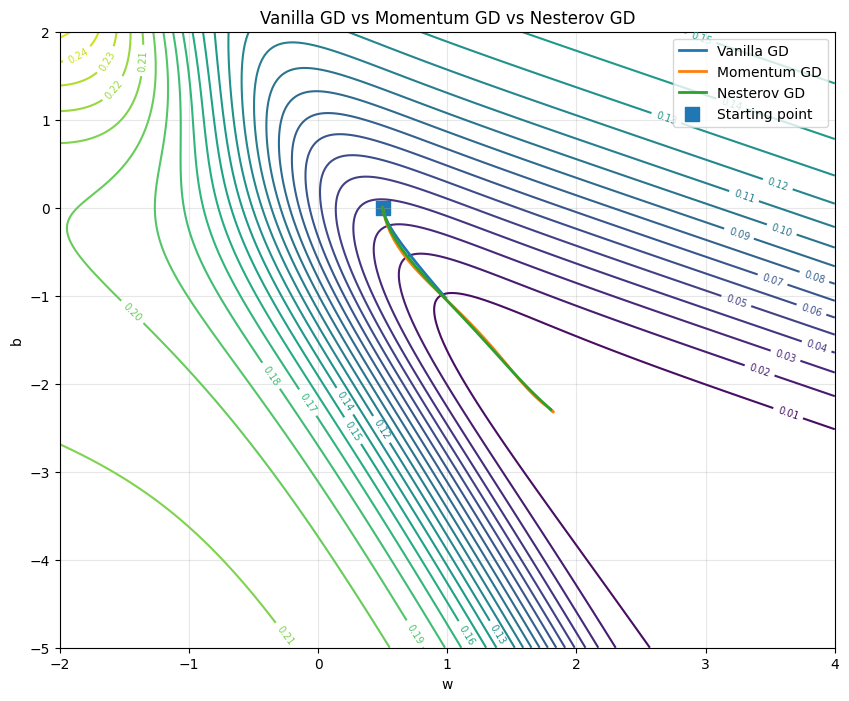

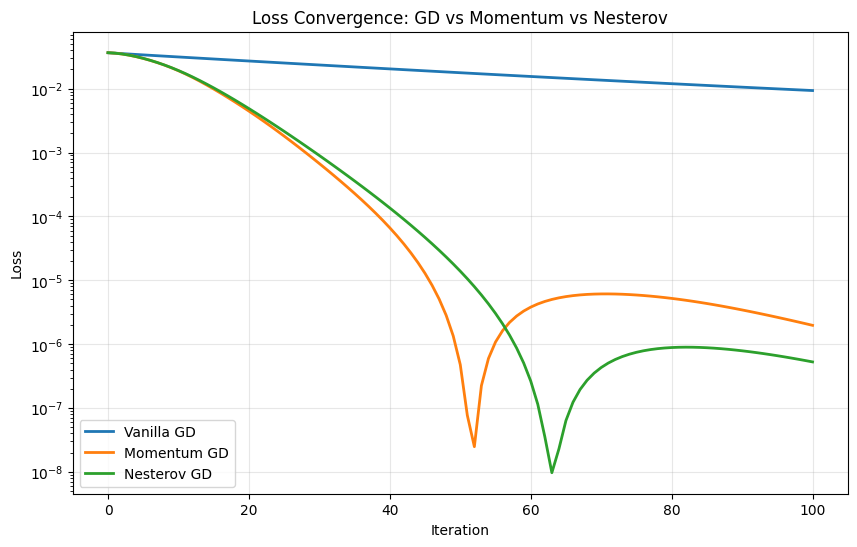

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# DATASET
# ============================================================

X = np.array([0.5, 2.5])
Y = np.array([0.2, 0.9])

W0 = 0.5
B0 = 0.0

LR = 0.5

EPOCHS = 100

# Momentum coefficient
BETA = 0.9


# ============================================================
# SIGMOID
# ============================================================

def sigmoid(z):

    return 1 / (
        1 + np.exp(
            -np.clip(z, -500, 500)
        )
    )


# ============================================================
# LOSS
# ============================================================

def loss(w, b):

    y_pred = sigmoid(w * X + b)

    return 0.5 * np.mean(
        (y_pred - Y) ** 2
    )


# ============================================================
# GRADIENT
# ============================================================

def gradient(w, b):

    y_pred = sigmoid(w * X + b)

    error = y_pred - Y

    grad_w = np.mean(
        error * y_pred *
        (1 - y_pred) * X
    )

    grad_b = np.mean(
        error * y_pred *
        (1 - y_pred)
    )

    return grad_w, grad_b


# ============================================================
# VANILLA GD
# ============================================================

def vanilla_gd():

    w = W0
    b = B0

    trajectory = [(w, b)]
    losses = [loss(w, b)]

    for epoch in range(EPOCHS):

        grad_w, grad_b = gradient(w, b)

        w -= LR * grad_w
        b -= LR * grad_b

        trajectory.append((w, b))
        losses.append(loss(w, b))

    return np.array(trajectory), np.array(losses)


# ============================================================
# MOMENTUM GD
# ============================================================

def momentum_gd():

    w = W0
    b = B0

    velocity_w = 0
    velocity_b = 0

    trajectory = [(w, b)]
    losses = [loss(w, b)]

    for epoch in range(EPOCHS):

        grad_w, grad_b = gradient(w, b)

        velocity_w = (
            BETA * velocity_w
            - LR * grad_w
        )

        velocity_b = (
            BETA * velocity_b
            - LR * grad_b
        )

        w += velocity_w
        b += velocity_b

        trajectory.append((w, b))
        losses.append(loss(w, b))

    return np.array(trajectory), np.array(losses)


# ============================================================
# NESTEROV ACCELERATED GRADIENT
# ============================================================

def nesterov():

    w = W0
    b = B0

    velocity_w = 0
    velocity_b = 0

    trajectory = [(w, b)]
    losses = [loss(w, b)]

    for epoch in range(EPOCHS):

        # Look-ahead position
        lookahead_w = (
            w + BETA * velocity_w
        )

        lookahead_b = (
            b + BETA * velocity_b
        )

        # Calculate gradient at look-ahead
        grad_w, grad_b = gradient(
            lookahead_w,
            lookahead_b
        )

        velocity_w = (
            BETA * velocity_w
            - LR * grad_w
        )

        velocity_b = (
            BETA * velocity_b
            - LR * grad_b
        )

        w += velocity_w
        b += velocity_b

        trajectory.append((w, b))
        losses.append(loss(w, b))

    return np.array(trajectory), np.array(losses)


# ============================================================
# ERROR SURFACE
# ============================================================

w_values = np.linspace(-2, 4, 300)
b_values = np.linspace(-5, 2, 300)

W, B = np.meshgrid(
    w_values,
    b_values
)

Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):

        Z[i, j] = loss(
            W[i, j],
            B[i, j]
        )


# ============================================================
# RUN OPTIMIZERS
# ============================================================

gd_traj, gd_loss = vanilla_gd()

momentum_traj, momentum_loss = momentum_gd()

nesterov_traj, nesterov_loss = nesterov()

def plot_trajectory(name, trajectory):

    plt.figure(figsize=(9, 7))

    # Error surface
    contours = plt.contour(
        W,
        B,
        Z,
        levels=25
    )

    plt.clabel(
        contours,
        inline=True,
        fontsize=7
    )

    # This optimizer only
    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        linewidth=2,
        marker="o",
        markersize=2
    )

    # Starting point
    plt.scatter(
        W0,
        B0,
        s=100,
        marker="s",
        label="Starting point"
    )

    # Final point
    plt.scatter(
        trajectory[-1, 0],
        trajectory[-1, 1],
        s=120,
        marker="*",
        label="Final point"
    )

    plt.xlabel("w")
    plt.ylabel("b")

    plt.title(
        f"{name} Optimization Trajectory"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()
    
plot_trajectory(
    "Vanilla Gradient Descent",
    gd_traj
)

plot_trajectory(
    "Momentum Gradient Descent",
    momentum_traj
)

plot_trajectory(
    "Nesterov Accelerated Gradient",
    nesterov_traj
)
# ============================================================
# TRAJECTORY COMPARISON
# ============================================================

plt.figure(figsize=(10, 8))

contours = plt.contour(
    W,
    B,
    Z,
    levels=25
)

plt.clabel(
    contours,
    inline=True,
    fontsize=7
)

plt.plot(
    gd_traj[:, 0],
    gd_traj[:, 1],
    linewidth=2,
    label="Vanilla GD"
)

plt.plot(
    momentum_traj[:, 0],
    momentum_traj[:, 1],
    linewidth=2,
    label="Momentum GD"
)

plt.plot(
    nesterov_traj[:, 0],
    nesterov_traj[:, 1],
    linewidth=2,
    label="Nesterov GD"
)

plt.scatter(
    W0,
    B0,
    s=100,
    marker="s",
    label="Starting point"
)

plt.xlabel("w")
plt.ylabel("b")

plt.title(
    "Vanilla GD vs Momentum GD vs Nesterov GD"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# LOSS COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    gd_loss,
    linewidth=2,
    label="Vanilla GD"
)

plt.plot(
    momentum_loss,
    linewidth=2,
    label="Momentum GD"
)

plt.plot(
    nesterov_loss,
    linewidth=2,
    label="Nesterov GD"
)

plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.title(
    "Loss Convergence: GD vs Momentum vs Nesterov"
)

plt.yscale("log")

plt.legend()
plt.grid(alpha=0.3)

plt.show()